In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import itertools
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 8)

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (Small Sample)
SAMPLE_STOCKS = ['360ONE', '3MINDIA', 'AARTIIND', 'ABB', 'ACC']

def load_data(stocks):
    all_data = []
    for symbol in stocks:
        file_path = os.path.join(DATA_DIR, f"{symbol}.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            df['Symbol'] = symbol
            all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

data = load_data(SAMPLE_STOCKS)


In [3]:
# 3. Regimes & ATR
def calculate_atr(df, period=14):
    df['H-L'] = df['High'] - df['Low']
    df['H-C'] = abs(df['High'] - df['Close'].shift(1))
    df['L-C'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-C', 'L-C']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=period).mean()
    return df

def calculate_static_er(data, lookback=14):
    data = data.copy()
    change = abs(data['Close'] - data['Close'].shift(lookback))
    volatility = data['Close'].diff().abs().rolling(lookback).sum()
    data['ER'] = change / volatility
    return data

def calculate_dynamic_er(data, target=0.50):
    data = data.copy()
    data['abs_ret'] = data['Close'].pct_change().abs()
    
    abs_rets = data['abs_ret'].values
    closes = data['Close'].values
    efficiency = np.full(len(data), np.nan)
    
    for i in range(len(data)):
        if i == 0 or np.isnan(abs_rets[i]):
            continue
            
        cum_sum = 0
        j = i
        while j >= 0 and cum_sum < target:
            if not np.isnan(abs_rets[j]):
                cum_sum += abs_rets[j]
            j -= 1
            
        if cum_sum >= target:
            net_return = (closes[i] - closes[j]) / closes[j]
            efficiency[i] = net_return / cum_sum
            
    data['ER'] = efficiency # Save to the same column name so backtester is blind to the type
    return data


In [4]:
# 4. The Vectorized Event-Driven Backtester
# We simulate Long-only trades with Dynamic Exits and ATR Trailing Stops

def backtest_strategy(df, entry_er, exit_er, atr_mult):
    trades = []
    in_trade = False
    entry_price = 0
    entry_date = None
    highest_price = 0
    stop_loss = 0
    
    for i, row in df.iterrows():
        # Check Exits first if we are in a trade
        if in_trade:
            # Update trailing stop
            if row['High'] > highest_price:
                highest_price = row['High']
                stop_loss = highest_price - (row['ATR'] * atr_mult)
            
            # Condition 1: Hit Trailing Stop
            if row['Low'] <= stop_loss:
                exit_price = stop_loss if row['Open'] > stop_loss else row['Open']
                ret = (exit_price - entry_price) / entry_price
                trades.append({'Symbol': row['Symbol'], 'Entry_Date': entry_date, 'Exit_Date': row['Date'], 'Return': ret, 'Exit_Reason': 'ATR Stop'})
                in_trade = False
                continue
                
            # Condition 2: ER Exit (Trend exhaustion)
            if row['ER'] < exit_er:
                exit_price = row['Close']
                ret = (exit_price - entry_price) / entry_price
                trades.append({'Symbol': row['Symbol'], 'Entry_Date': entry_date, 'Exit_Date': row['Date'], 'Return': ret, 'Exit_Reason': 'ER Exit'})
                in_trade = False
                continue
                
        # Check Entries if we are NOT in a trade
        if not in_trade:
            # Condition: ER spikes above entry threshold
            if pd.notna(row['ER']) and row['ER'] > entry_er:
                in_trade = True
                entry_price = row['Close']
                entry_date = row['Date']
                highest_price = row['High']
                stop_loss = highest_price - (row['ATR'] * atr_mult)
                
    return trades


In [5]:
# 5. Dual Recursive Walk-Forward Optimizer (Static vs Dynamic)
STATIC_LOOKBACKS = [10, 20, 30]
DYNAMIC_TARGETS = [0.10, 0.30, 0.50]

ENTRY_ERS = [0.3, 0.5, 0.7]
EXIT_ERS = [0.1, 0.2]
ATR_MULTS = [1.5, 3.0]

TRAIN_END_DATE = '2023-01-01'
leaderboard = []

best_score = -9999
best_params = None
best_test_trades = None

print("Starting Walk-Forward Optimization...")

# Pre-calculate ATR for all stocks
_data_list = []
for sym, grp in data.groupby('Symbol'):
    _data_list.append(calculate_atr(grp.copy()))
data = pd.concat(_data_list, ignore_index=True)

# Helper function to run the grid search
def run_grid_search(temp_df, strategy_type, target_val):
    global best_score, best_params, best_test_trades
    
    train_df = temp_df[temp_df['Date'] < TRAIN_END_DATE]
    test_df = temp_df[temp_df['Date'] >= TRAIN_END_DATE]
    
    for entry_er, exit_er, atr_mult in itertools.product(ENTRY_ERS, EXIT_ERS, ATR_MULTS):
        if entry_er <= exit_er: continue
        
        # 1. Backtest Training
        train_trades_list = []
        for sym, grp in train_df.groupby('Symbol'):
            train_trades_list.extend(backtest_strategy(grp, entry_er, exit_er, atr_mult))
            
        train_trades = pd.DataFrame(train_trades_list)
        if len(train_trades) < 5: continue
        if (train_trades['Return'] > 0).mean() < 0.40: continue # Skip losers
            
        # 2. Backtest Unseen Data
        test_trades_list = []
        for sym, grp in test_df.groupby('Symbol'):
            test_trades_list.extend(backtest_strategy(grp, entry_er, exit_er, atr_mult))
            
        test_trades = pd.DataFrame(test_trades_list)
        if len(test_trades) < 2: continue
            
        # 3. Calculate Fitness
        test_winrate = (test_trades['Return'] > 0).mean()
        test_avg_ret = test_trades['Return'].mean()
        
        test_trades = test_trades.sort_values('Exit_Date').reset_index(drop=True)
        equity = 10000 * (1 + test_trades['Return']).cumprod()
        drawdown = ((equity / equity.cummax()) - 1).min()
        drawdown = abs(drawdown) if drawdown < 0 else 0.01
        
        fitness = (test_winrate * test_avg_ret) / drawdown
        
        params_str = f"Type:{strategy_type}|Val:{target_val}|In:{entry_er}|Out:{exit_er}|ATR:{atr_mult}"
        
        leaderboard.append({
            'Type': strategy_type,
            'Params': params_str,
            'Test_Trades': len(test_trades),
            'Test_WinRate': test_winrate * 100,
            'Test_AvgReturn': test_avg_ret * 100,
            'Test_Drawdown': drawdown * 100,
            'Fitness': fitness
        })
        
        if fitness > best_score:
            best_score = fitness
            best_params = params_str
            test_trades['Equity'] = equity
            best_test_trades = test_trades


# PHASE 1: Static ER
for lookback in STATIC_LOOKBACKS:
    print(f"Calculating Static ER for Lookback={lookback}...")
    _temp_list = []
    for sym, grp in data.groupby('Symbol'):
        _temp_list.append(calculate_static_er(grp.copy(), lookback))
    temp_df = pd.concat(_temp_list, ignore_index=True)
    run_grid_search(temp_df, 'STATIC', lookback)
    
# PHASE 2: Dynamic ER
for target in DYNAMIC_TARGETS:
    print(f"Calculating Dynamic ER for Target={target}...")
    _temp_list = []
    for sym, grp in data.groupby('Symbol'):
        _temp_list.append(calculate_dynamic_er(grp.copy(), target))
    temp_df = pd.concat(_temp_list, ignore_index=True)
    run_grid_search(temp_df, 'DYNAMIC', target)

leaderboard_df = pd.DataFrame(leaderboard).sort_values('Fitness', ascending=False).reset_index(drop=True)
display(HTML("<h3>Leaderboard Showdown (Tested on Unseen 2023+ Data)</h3>"))
display(leaderboard_df.head(15))


Starting Walk-Forward Optimization...
Calculating Static ER for Lookback=10...


Calculating Static ER for Lookback=20...


Calculating Static ER for Lookback=30...


Calculating Dynamic ER for Target=0.1...


Calculating Dynamic ER for Target=0.3...


Calculating Dynamic ER for Target=0.5...


,Type,Params,Test_Trades,Test_WinRate,Test_AvgReturn,Test_Drawdown,Fitness
0,STATIC,Type:STATIC|Val:10|In:0.7|Out:0.1|ATR:3.0,125,56.000000,1.286336,23.231176,0.031008
1,STATIC,Type:STATIC|Val:10|In:0.7|Out:0.2|ATR:3.0,128,53.906250,1.016825,29.186989,0.018780
2,DYNAMIC,Type:DYNAMIC|Val:0.1|In:0.5|Out:0.2|ATR:3.0,137,46.715328,0.639387,40.501953,0.007375
3,DYNAMIC,Type:DYNAMIC|Val:0.1|In:0.5|Out:0.1|ATR:3.0,136,44.852941,0.504507,49.293354,0.004591
4,DYNAMIC,Type:DYNAMIC|Val:0.1|In:0.3|Out:0.2|ATR:3.0,202,43.069307,0.371479,37.355633,0.004283
5,STATIC,Type:STATIC|Val:10|In:0.5|Out:0.1|ATR:3.0,231,51.948052,0.526915,64.159368,0.004266
6,STATIC,Type:STATIC|Val:30|In:0.3|Out:0.2|ATR:3.0,139,54.676259,0.327555,43.408856,0.004126
7,DYNAMIC,Type:DYNAMIC|Val:0.1|In:0.7|Out:0.2|ATR:3.0,100,44.000000,0.352609,42.667012,0.003636
8,DYNAMIC,Type:DYNAMIC|Val:0.1|In:0.3|Out:0.1|ATR:3.0,186,41.935484,0.355021,49.227959,0.003024
9,STATIC,Type:STATIC|Val:10|In:0.5|Out:0.2|ATR:3.0,250,48.800000,0.377694,67.444333,0.002733



🏆 CHAMPION STRATEGY: Type:STATIC|Val:10|In:0.7|Out:0.1|ATR:3.0


,Symbol,Entry_Date,Exit_Date,Return,Exit_Reason,Equity
0,3MINDIA,2023-01-02,2023-01-06,0.036674,ER Exit,10366.740539
1,AARTIIND,2023-01-16,2023-01-23,-0.031180,ATR Stop,10043.509799
2,AARTIIND,2023-01-24,2023-01-27,-0.040946,ATR Stop,9632.268912
3,ABB,2023-01-12,2023-01-27,-0.036827,ATR Stop,9277.546105
4,ACC,2023-01-27,2023-01-30,0.016132,ATR Stop,9427.215503


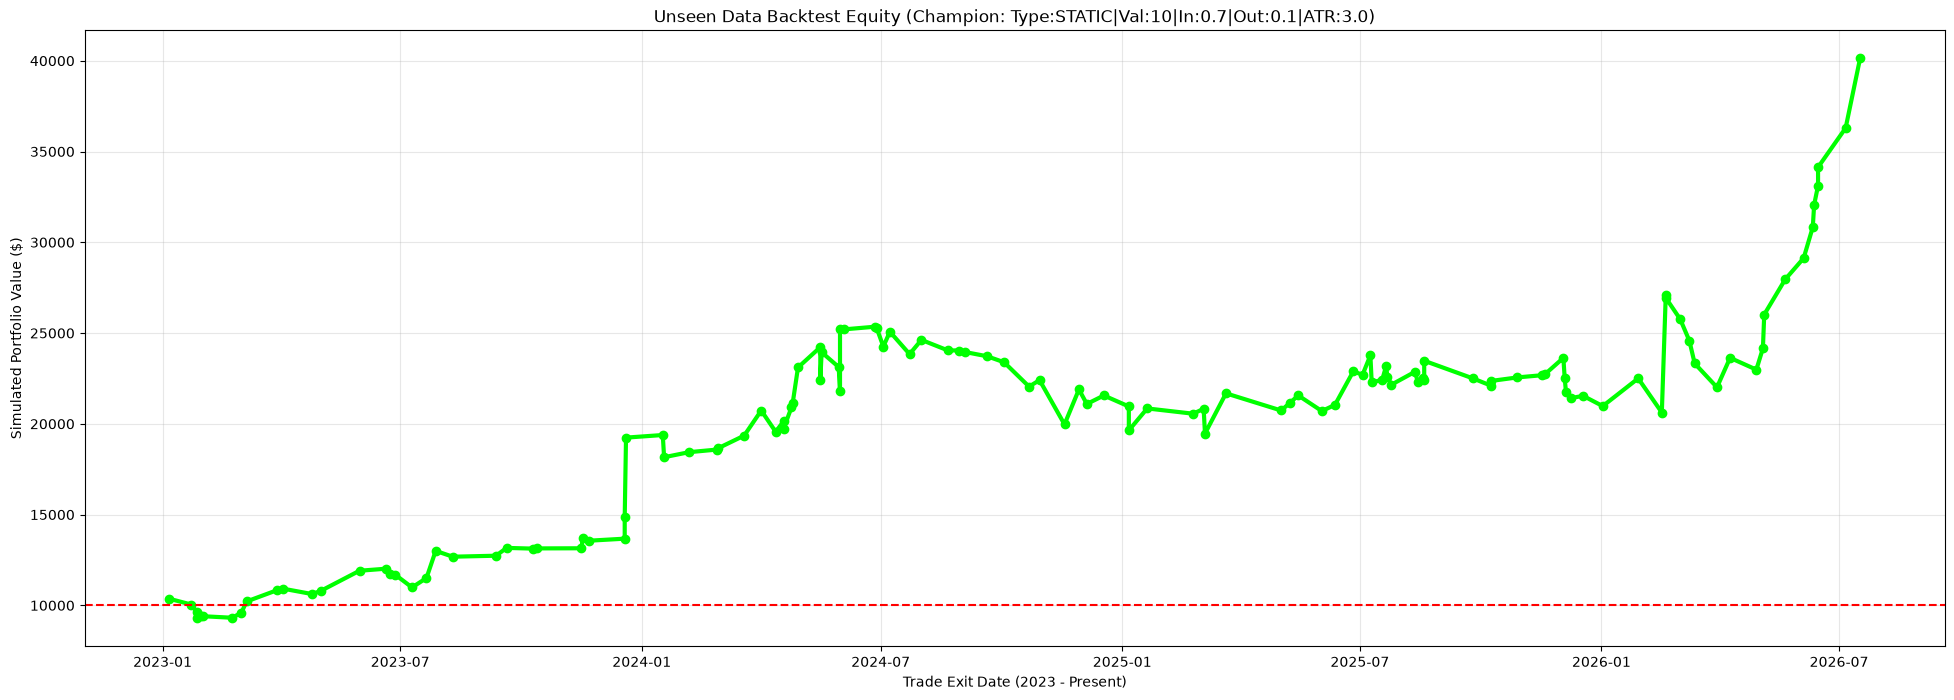

In [6]:
# 6. Review the Ultimate Champion
print(f"\n🏆 CHAMPION STRATEGY: {best_params}")
print("=============================================")
display(best_test_trades.head())

plt.figure(figsize=(24, 8))
plt.plot(best_test_trades['Exit_Date'], best_test_trades['Equity'], color='lime', linewidth=3, marker='o')
plt.title(f"Unseen Data Backtest Equity (Champion: {best_params})")
plt.ylabel("Simulated Portfolio Value ($)")
plt.xlabel("Trade Exit Date (2023 - Present)")
plt.grid(True, alpha=0.3)
plt.axhline(y=10000, color='red', linestyle='--')
plt.show()
